# Classificacao de Cancer de Pulmao com CNN

Este notebook usa o dataset [IQ-OTH/NCCD](https://data.mendeley.com/datasets/bhmdr45bh2/4) em JPG para treinar uma CNN simples em `TensorFlow/Keras`.

## Objetivo

- entrada: uma imagem de slice de CT em formato JPG
- classes de origem: `Normal cases`, `Bengin cases`(nomeado dessa forma pelo dataset apesar da nomenclatura correta ser 'benign'), `Malignant cases`
- alvo de treino: `0 = nao_maligno`, `1 = maligno`
- saida final: probabilidade de malignidade da imagem

In [1]:

from pathlib import Path
import json
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix,
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    average_precision_score,
)


## Funcoes Auxiliares

Estas funcoes leem o dataset, montam os splits e carregam as imagens.


In [2]:

CLASS_INFO = {
    "Normal cases": {"label": 0, "display": "Normal"},
    "Bengin cases": {"label": 0, "display": "Benigno"},
    "Malignant cases": {"label": 1, "display": "Maligno"},
}

LABEL_NAMES = {
    0: "nao_maligno",
    1: "maligno",
}

PREDICTION_DISPLAY = {
    "nao_maligno": "Nao maligno",
    "maligno": "Maligno",
}


def nome_exibicao_classe(nome_pasta):
    return CLASS_INFO[nome_pasta]["display"]


def definir_semente(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)


def coletar_registros_imagens(dataset_dir):
    dataset_dir = Path(dataset_dir)
    linhas = []
    for nome_pasta, info in CLASS_INFO.items():
        pasta = dataset_dir / nome_pasta
        if not pasta.exists():
            print(f"Aviso: pasta nao encontrada: {pasta}")
            continue
        for image_path in sorted(pasta.glob("*.jpg")):
            linhas.append(
                {
                    "image_path": str(image_path),
                    "classe_original": nome_pasta,
                    "label": info["label"],
                }
            )
    if not linhas:
        raise FileNotFoundError(f"Nenhuma imagem JPG foi encontrada em {dataset_dir}")
    frame = pd.DataFrame(linhas)
    return frame.sample(frac=1.0, random_state=42).reset_index(drop=True)


def resumir_dataset(registros):
    print("Contagem por rotulo binario:")
    print(registros["label"].value_counts().sort_index().rename(index=LABEL_NAMES))
    print()
    print("Contagem por classe:")
    print(registros["classe_original"].map(nome_exibicao_classe).value_counts().sort_index())


def split_estratificado(registros, seed=42, val_fraction=0.15, test_fraction=0.15):
    if val_fraction + test_fraction >= 1.0:
        raise ValueError("val_fraction + test_fraction deve ser menor que 1.")

    temp_fraction = val_fraction + test_fraction
    treino_df, temp_df = train_test_split(
        registros,
        test_size=temp_fraction,
        stratify=registros["label"],
        random_state=seed,
    )

    fracao_teste_relativa = test_fraction / temp_fraction
    val_df, teste_df = train_test_split(
        temp_df,
        test_size=fracao_teste_relativa,
        stratify=temp_df["label"],
        random_state=seed,
    )

    treino_df = treino_df.reset_index(drop=True)
    val_df = val_df.reset_index(drop=True)
    teste_df = teste_df.reset_index(drop=True)
    return treino_df, val_df, teste_df


def carregar_tensor_imagem(image_path, image_size=224):
    image = keras.utils.load_img(
        image_path,
        color_mode="rgb",
        target_size=(image_size, image_size),
    )
    array = keras.utils.img_to_array(image).astype("float32")
    return array


def montar_dataset_numpy(registros, image_size=224):
    imagens = []
    labels = []
    for row in tqdm(registros.itertuples(index=False), total=len(registros), desc="Carregando imagens"):
        imagens.append(carregar_tensor_imagem(row.image_path, image_size=image_size))
        labels.append(float(row.label))
    x = np.asarray(imagens, dtype=np.float32)
    y = np.asarray(labels, dtype=np.float32)
    return x, y


def calcular_class_weights(y_train):
    y_train = np.asarray(y_train).astype(np.int32)
    total = len(y_train)
    negativos = max(int(np.sum(y_train == 0)), 1)
    positivos = max(int(np.sum(y_train == 1)), 1)
    return {
        0: total / (2.0 * negativos),
        1: total / (2.0 * positivos),
    }


def mostrar_exemplos(registros, amostras_por_classe=3, image_size=224):
    fig, axes = plt.subplots(len(CLASS_INFO), amostras_por_classe, figsize=(4 * amostras_por_classe, 9))
    if amostras_por_classe == 1:
        axes = np.expand_dims(axes, axis=1)

    for row_index, nome_pasta in enumerate(CLASS_INFO):
        subconjunto = registros[registros["classe_original"] == nome_pasta].head(amostras_por_classe)
        for col_index in range(amostras_por_classe):
            ax = axes[row_index, col_index]
            ax.axis("off")
            if col_index >= len(subconjunto):
                continue
            image_path = subconjunto.iloc[col_index]["image_path"]
            image = keras.utils.load_img(
                image_path,
                color_mode="rgb",
                target_size=(image_size, image_size),
            )
            ax.imshow(image)
            ax.set_title(nome_exibicao_classe(nome_pasta))

    plt.tight_layout()
    plt.show()



## Modelo

Esta versao usa `transfer learning` com `EfficientNetB0`, o que costuma funcionar melhor do que uma CNN pequena treinada do zero.


In [3]:

def criar_metricas_modelo():
    return [
        "accuracy",
        keras.metrics.AUC(name="auc"),
        keras.metrics.Precision(name="precision"),
        keras.metrics.Recall(name="recall"),
    ]


def construir_modelo(image_size=224, fine_tune=False, learning_rate=1e-4):
    aumento_dados = keras.Sequential(
        [
            keras.layers.RandomFlip("horizontal"),
            keras.layers.RandomRotation(0.03),
            keras.layers.RandomZoom(0.08),
            keras.layers.RandomContrast(0.1),
        ],
        name="aumento_dados",
    )

    base_model = keras.applications.EfficientNetB0(
        include_top=False,
        weights="imagenet",
        input_shape=(image_size, image_size, 3),
    )
    base_model.trainable = fine_tune

    inputs = keras.Input(shape=(image_size, image_size, 3))
    x = aumento_dados(inputs)
    x = keras.applications.efficientnet.preprocess_input(x)
    x = base_model(x, training=False)
    x = keras.layers.GlobalAveragePooling2D()(x)
    x = keras.layers.Dropout(0.35)(x)
    x = keras.layers.Dense(128, activation="relu")(x)
    x = keras.layers.Dropout(0.2)(x)
    outputs = keras.layers.Dense(1, activation="sigmoid")(x)

    model = keras.Model(inputs, outputs)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss="binary_crossentropy",
        metrics=criar_metricas_modelo(),
    )
    return model, base_model



## Funcoes de Treino e Avaliacao

Esta secao calcula `class_weight`, treina em duas fases e escolhe o melhor limiar com prioridade para recall.


In [4]:

def calcular_metricas_binarias(y_true, y_prob, threshold=0.5):
    y_true = np.asarray(y_true).astype(np.int32)
    y_prob = np.asarray(y_prob).astype(np.float32)
    y_pred = (y_prob >= threshold).astype(np.int32)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    accuracy = float((tp + tn) / max(len(y_true), 1))
    precision = float(tp / max(tp + fp, 1))
    recall = float(tp / max(tp + fn, 1))
    specificity = float(tn / max(tn + fp, 1))
    f1 = float((2 * precision * recall) / max(precision + recall, 1e-8))

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "specificity": specificity,
        "f1": f1,
        "tp": int(tp),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
    }


def escolher_melhor_limiar(y_true, y_prob, prioridade="recall"):
    y_true = np.asarray(y_true).astype(np.int32)
    y_prob = np.asarray(y_prob).astype(np.float32)
    candidatos = np.linspace(0.1, 0.9, 81)

    melhor_threshold = 0.5
    melhor_metricas = None
    melhor_score = -1.0

    for threshold in candidatos:
        metricas = calcular_metricas_binarias(y_true, y_prob, threshold=threshold)
        if prioridade == "recall":
            score = metricas["recall"] * 2.0 + metricas["specificity"] + metricas["f1"]
        else:
            score = metricas["accuracy"] + metricas["f1"]
        if score > melhor_score:
            melhor_score = score
            melhor_threshold = float(threshold)
            melhor_metricas = metricas

    return melhor_threshold, melhor_metricas


def avaliar_probabilidades(y_true, y_prob, threshold=0.5):
    metricas = calcular_metricas_binarias(y_true, y_prob, threshold=threshold)
    y_true = np.asarray(y_true).astype(np.int32)
    y_prob = np.asarray(y_prob).astype(np.float32)

    try:
        auc_roc = float(roc_auc_score(y_true, y_prob))
    except ValueError:
        auc_roc = None

    try:
        avg_precision = float(average_precision_score(y_true, y_prob))
    except ValueError:
        avg_precision = None

    metricas["auc_roc"] = auc_roc
    metricas["average_precision"] = avg_precision
    metricas["threshold"] = float(threshold)
    return metricas


def criar_callbacks(checkpoint_path):
    return [
        keras.callbacks.ModelCheckpoint(
            filepath=str(checkpoint_path),
            monitor="val_auc",
            mode="max",
            save_best_only=True,
        ),
        keras.callbacks.EarlyStopping(
            monitor="val_auc",
            mode="max",
            patience=4,
            restore_best_weights=True,
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_auc",
            mode="max",
            factor=0.5,
            patience=2,
            min_lr=1e-6,
        ),
    ]


def treinar_modelo(
    dataset_dir,
    output_dir,
    epochs=8,
    batch_size=16,
    lr=1e-4,
    image_size=224,
    val_fraction=0.15,
    test_fraction=0.15,
    seed=42,
    usar_class_weight=True,
    fine_tune_epochs=3,
):
    definir_semente(seed)
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    registros = coletar_registros_imagens(dataset_dir)
    resumir_dataset(registros)
    registros.to_csv(output_dir / "all_records.csv", index=False)

    treino_df, val_df, teste_df = split_estratificado(
        registros,
        seed=seed,
        val_fraction=val_fraction,
        test_fraction=test_fraction,
    )
    treino_df.to_csv(output_dir / "train_records.csv", index=False)
    val_df.to_csv(output_dir / "val_records.csv", index=False)
    teste_df.to_csv(output_dir / "test_records.csv", index=False)

    x_train, y_train = montar_dataset_numpy(treino_df, image_size=image_size)
    x_val, y_val = montar_dataset_numpy(val_df, image_size=image_size)
    x_test, y_test = montar_dataset_numpy(teste_df, image_size=image_size)

    class_weight = calcular_class_weights(y_train) if usar_class_weight else None
    print("Class weights:", class_weight)

    model, base_model = construir_modelo(
        image_size=image_size,
        fine_tune=False,
        learning_rate=lr,
    )

    checkpoint_path = output_dir / "best.keras"
    callbacks = criar_callbacks(checkpoint_path)

    history_inicial = model.fit(
        x_train,
        y_train,
        validation_data=(x_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=callbacks,
        verbose=1,
        class_weight=class_weight,
    )

    histories = [history_inicial.history]

    if fine_tune_epochs > 0:
        base_model.trainable = True
        for layer in base_model.layers[:-20]:
            layer.trainable = False

        model.compile(
            optimizer=keras.optimizers.Adam(learning_rate=lr / 10.0),
            loss="binary_crossentropy",
            metrics=criar_metricas_modelo(),
        )

        history_finetune = model.fit(
            x_train,
            y_train,
            validation_data=(x_val, y_val),
            epochs=fine_tune_epochs,
            batch_size=batch_size,
            callbacks=callbacks,
            verbose=1,
            class_weight=class_weight,
        )
        histories.append(history_finetune.history)

    melhor_modelo = keras.models.load_model(checkpoint_path)

    y_prob_val = melhor_modelo.predict(x_val, verbose=0).ravel()
    melhor_threshold, metricas_val = escolher_melhor_limiar(y_val, y_prob_val, prioridade="recall")

    y_prob_test = melhor_modelo.predict(x_test, verbose=0).ravel()
    metricas_teste = avaliar_probabilidades(y_test, y_prob_test, threshold=melhor_threshold)

    history_total = {}
    for hist in histories:
        for chave, valores in hist.items():
            history_total.setdefault(chave, []).extend(valores)

    metadata = {
        "image_size": image_size,
        "class_names": LABEL_NAMES,
        "positive_class": "maligno",
        "negative_class": "nao_maligno",
        "dataset_dir": str(dataset_dir),
        "best_threshold": float(melhor_threshold),
        "class_weight": class_weight,
        "fine_tune_epochs": int(fine_tune_epochs),
        "backbone": "EfficientNetB0",
    }

    with (output_dir / "best_info.json").open("w", encoding="utf-8") as file:
        json.dump(metadata, file, indent=2)

    with (output_dir / "metrics.json").open("w", encoding="utf-8") as file:
        json.dump(
            {
                "history": history_total,
                "validation_metrics": metricas_val,
                "test_metrics": metricas_teste,
                "train_images": len(treino_df),
                "val_images": len(val_df),
                "test_images": len(teste_df),
                **metadata,
            },
            file,
            indent=2,
        )

    print("Modelo salvo em:", checkpoint_path)
    print("Melhor limiar encontrado na validacao:", round(melhor_threshold, 4))
    print("Metricas de teste:", metricas_teste)

    resultados = {
        "treino_df": treino_df,
        "val_df": val_df,
        "teste_df": teste_df,
        "x_test": x_test,
        "y_test": y_test,
        "y_prob_test": y_prob_test,
        "melhor_threshold": melhor_threshold,
        "metricas_teste": metricas_teste,
    }
    return melhor_modelo, history_total, resultados


def plotar_curvas_treino(history):
    if not history:
        print("Historico vazio.")
        return

    metricas = [
        ("loss", "Loss"),
        ("accuracy", "Accuracy"),
        ("auc", "AUC"),
        ("recall", "Recall"),
    ]
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    axes = axes.ravel()

    for ax, (chave, titulo) in zip(axes, metricas):
        ax.plot(history.get(chave, []), label="treino")
        ax.plot(history.get(f"val_{chave}", []), label="validacao")
        ax.set_title(titulo)
        ax.legend()

    plt.tight_layout()
    plt.show()


def plotar_matriz_confusao(y_true, y_prob, threshold=0.5):
    y_true = np.asarray(y_true).astype(np.int32)
    y_pred = (np.asarray(y_prob) >= threshold).astype(np.int32)
    matriz = confusion_matrix(y_true, y_pred, labels=[0, 1])

    fig, ax = plt.subplots(figsize=(5, 4))
    im = ax.imshow(matriz, cmap="Blues")
    ax.set_title("Matriz de Confusao")
    ax.set_xlabel("Predito")
    ax.set_ylabel("Real")
    ax.set_xticks([0, 1], ["nao_maligno", "maligno"])
    ax.set_yticks([0, 1], ["nao_maligno", "maligno"])

    for i in range(matriz.shape[0]):
        for j in range(matriz.shape[1]):
            ax.text(j, i, str(matriz[i, j]), ha="center", va="center", color="black")

    fig.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.show()


def plotar_curva_roc(y_true, y_prob):
    y_true = np.asarray(y_true).astype(np.int32)
    y_prob = np.asarray(y_prob).astype(np.float32)
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc = roc_auc_score(y_true, y_prob)

    plt.figure(figsize=(5, 4))
    plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
    plt.plot([0, 1], [0, 1], "--", color="gray")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("Curva ROC")
    plt.legend()
    plt.tight_layout()
    plt.show()


def plotar_curva_precision_recall(y_true, y_prob):
    y_true = np.asarray(y_true).astype(np.int32)
    y_prob = np.asarray(y_prob).astype(np.float32)
    precision, recall, _ = precision_recall_curve(y_true, y_prob)
    ap = average_precision_score(y_true, y_prob)

    plt.figure(figsize=(5, 4))
    plt.plot(recall, precision, label=f"AP = {ap:.4f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Curva Precision-Recall")
    plt.legend()
    plt.tight_layout()
    plt.show()


## Caminhos e Configuracoes

Atualize estes valores se o dataset estiver em outro local.


In [5]:

DATASET_DIR = Path(r"C:/Users/Usuario/Documents/Lung Cancer/The IQ-OTHNCCD lung cancer dataset/The IQ-OTHNCCD lung cancer dataset/The IQ-OTHNCCD lung cancer dataset/The IQ-OTHNCCD lung cancer dataset")
OUTPUT_DIR = Path(r"c:/Coding/studies/python/computer_vision/lung_cancer_detection/training_output")

IMAGE_SIZE = 224
EPOCHS = 8
BATCH_SIZE = 16
LEARNING_RATE = 1e-4
SEED = 42
FINE_TUNE_EPOCHS = 3
USAR_CLASS_WEIGHT = True


## Explorar o Dataset


Contagem por rotulo binario:
label
nao_maligno    536
maligno        561
Name: count, dtype: int64

Contagem por classe:
classe_original
Benigno    120
Maligno    561
Normal     416
Name: count, dtype: int64


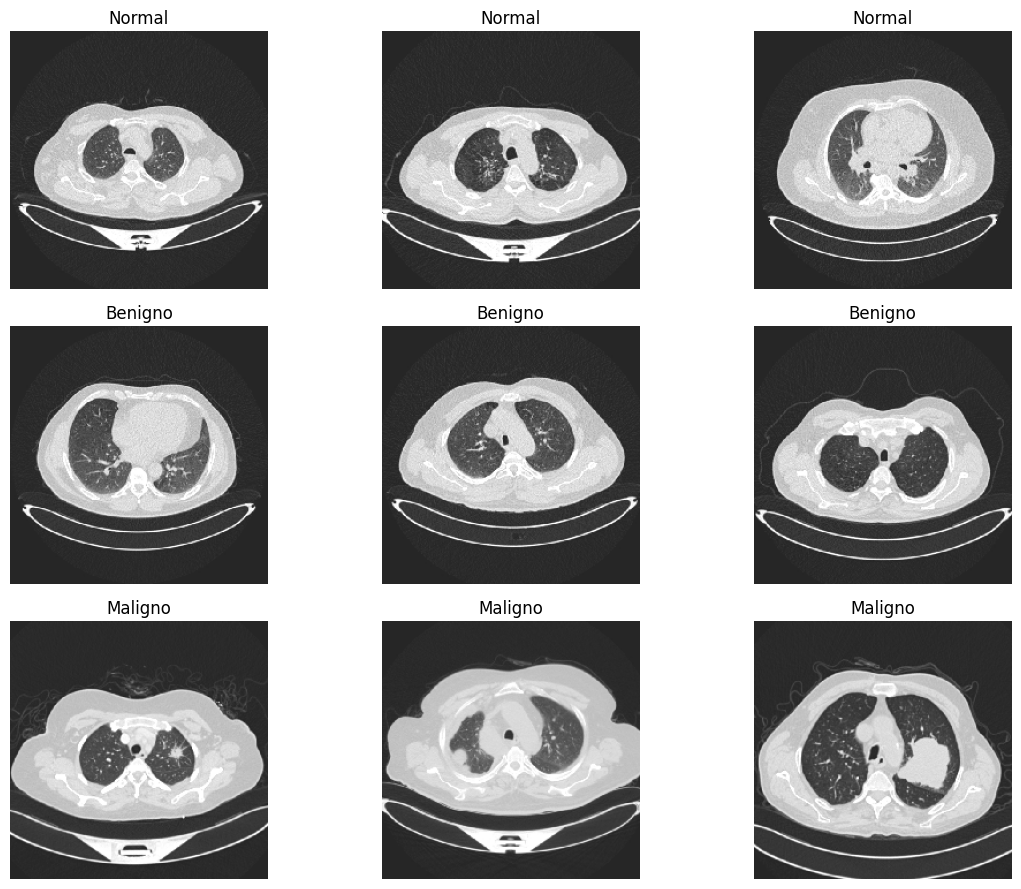

In [6]:
registros = coletar_registros_imagens(DATASET_DIR)
resumir_dataset(registros)
mostrar_exemplos(registros, amostras_por_classe=3, image_size=IMAGE_SIZE)

## Treino

Esta etapa usa o dataset completo encontrado em `DATASET_DIR`.


Contagem por rotulo binario:
label
nao_maligno    536
maligno        561
Name: count, dtype: int64

Contagem por classe:
classe_original
Benigno    120
Maligno    561
Normal     416
Name: count, dtype: int64


Carregando imagens: 100%|██████████| 165/165 [00:00<00:00, 341.68it/s]


Class weights: {0: 1.0226666666666666, 1: 0.9783163265306123}
Epoch 1/8
48/48 ━━━━━━━━━━━━━━━━━━━━ 23s 289ms/step - accuracy: 0.7432 - auc: 0.8365 - loss: 0.5241 - precision: 0.7746 - recall: 0.7015 - val_accuracy: 0.9091 - val_auc: 0.9912 - val_loss: 0.3241 - val_precision: 0.9861 - val_recall: 0.8353 - learning_rate: 1.0000e-04
Epoch 2/8
48/48 ━━━━━━━━━━━━━━━━━━━━ 11s 229ms/step - accuracy: 0.9400 - auc: 0.9863 - loss: 0.2712 - precision: 0.9347 - recall: 0.9490 - val_accuracy: 0.8667 - val_auc: 0.9929 - val_loss: 0.2521 - val_precision: 0.9846 - val_recall: 0.7529 - learning_rate: 1.0000e-04
Epoch 3/8
48/48 ━━━━━━━━━━━━━━━━━━━━ 12s 241ms/step - accuracy: 0.9465 - auc: 0.9912 - loss: 0.1830 - precision: 0.9558 - recall: 0.9388 - val_accuracy: 0.8848 - val_auc: 0.9943 - val_loss: 0.2186 - val_precision: 0.9853 - val_recall: 0.7882 - learning_rate: 1.0000e-04
Epoch 4/8
48/48 ━━━━━━━━━━━━━━━━━━━━ 11s 235ms/step - accuracy: 0.9596 - auc: 0.9936 - loss: 0.1413 - precision: 0.9570 - recall

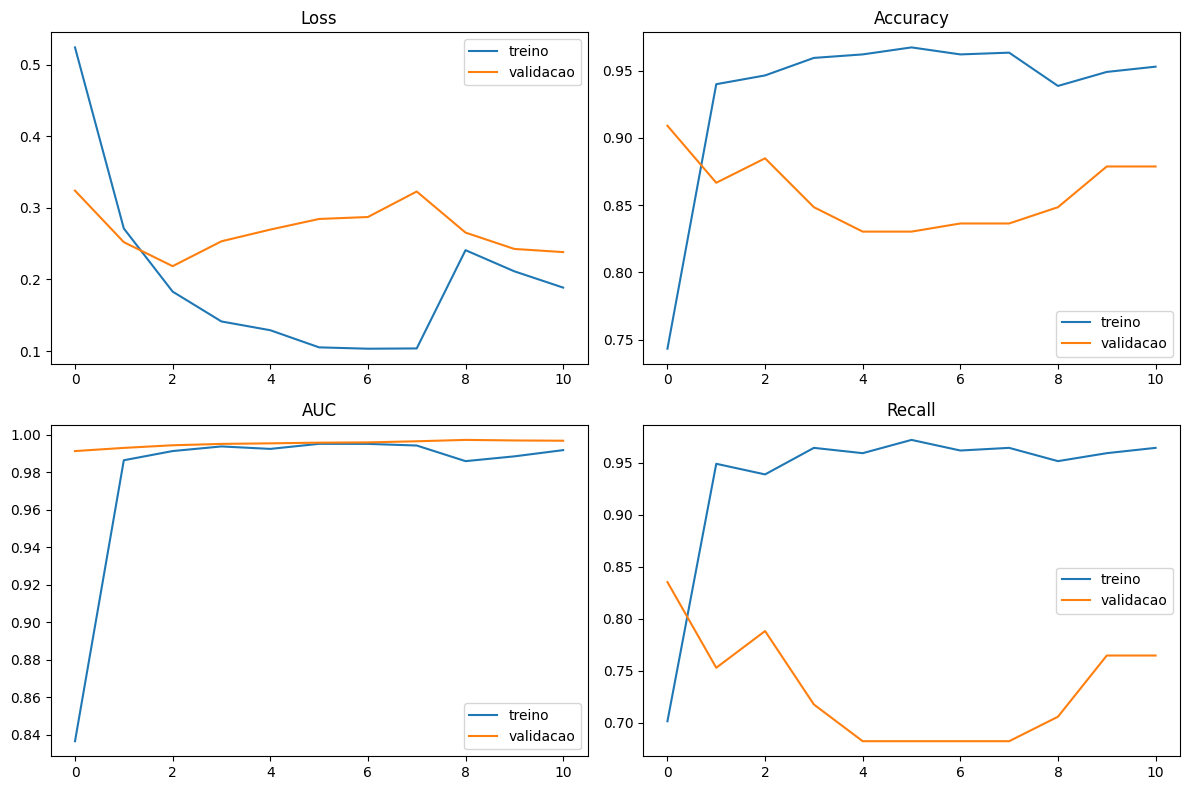

In [7]:

modelo, history, resultados = treinar_modelo(
    dataset_dir=DATASET_DIR,
    output_dir=OUTPUT_DIR,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    lr=LEARNING_RATE,
    image_size=IMAGE_SIZE,
    seed=SEED,
    usar_class_weight=USAR_CLASS_WEIGHT,
    fine_tune_epochs=FINE_TUNE_EPOCHS,
)
plotar_curvas_treino(history)


## Avaliacao

Execute estas celulas depois do treino para visualizar as metricas finais.


{'accuracy': 0.9636363636363636, 'precision': 0.975609756097561, 'recall': 0.9523809523809523, 'specificity': 0.9753086419753086, 'f1': 0.963855421686747, 'tp': 80, 'tn': 79, 'fp': 2, 'fn': 4, 'auc_roc': 0.9973544973544974, 'average_precision': 0.9975018132452673, 'threshold': 0.1}


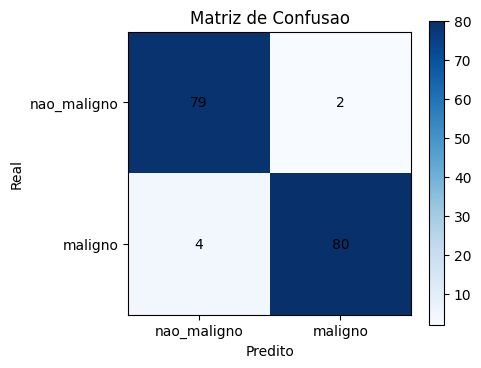

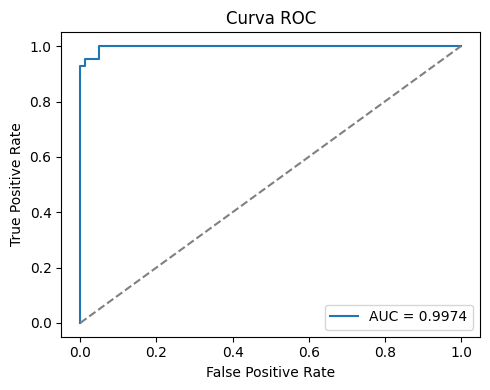

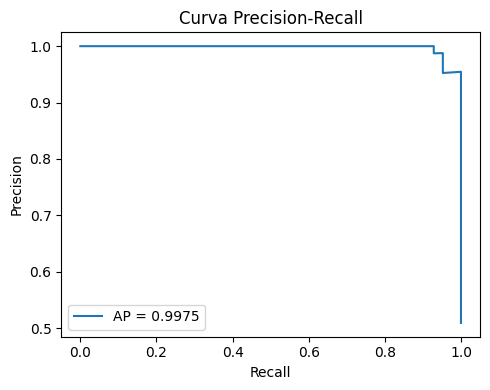

In [8]:
print(resultados["metricas_teste"])
plotar_matriz_confusao(
    resultados["y_test"],
    resultados["y_prob_test"],
    threshold=resultados["melhor_threshold"],
)

plotar_curva_roc(resultados["y_test"], resultados["y_prob_test"])
plotar_curva_precision_recall(resultados["y_test"], resultados["y_prob_test"])


## Inferencia

Esta funcao recebe uma imagem JPG inteira e devolve a probabilidade de malignidade.


In [9]:
def carregar_modelo_treinado(checkpoint_path):
    checkpoint_path = Path(checkpoint_path)
    metadata_path = checkpoint_path.with_name("best_info.json")
    metadata = {}

    if metadata_path.exists():
        with metadata_path.open("r", encoding="utf-8") as file:
            metadata = json.load(file)

    model = keras.models.load_model(checkpoint_path)
    image_size = metadata.get("image_size", 224)
    threshold = metadata.get("best_threshold", 0.5)
    return model, image_size, threshold


def prever_com_modelo(model, image_path, image_size, threshold=0.5, verbose=True):
    image = carregar_tensor_imagem(str(image_path), image_size=image_size)
    probability = float(model.predict(image[np.newaxis, ...], verbose=0)[0][0])
    prediction = "maligno" if probability >= threshold else "nao_maligno"

    if verbose:
        print(f"probabilidade_malignidade={probability:.4f}")
        print(f"limiar_utilizado={float(threshold):.4f}")
        print(f"classe_predita={PREDICTION_DISPLAY[prediction]}")
    return probability, prediction


def prever_imagem(checkpoint_path, image_path, image_size=None, threshold=None, verbose=True):
    model, image_size_salvo, threshold_salvo = carregar_modelo_treinado(checkpoint_path)
    image_size = image_size or image_size_salvo
    threshold = threshold if threshold is not None else threshold_salvo
    return prever_com_modelo(model, image_path, image_size=image_size, threshold=threshold, verbose=verbose)


In [10]:
def demonstrar_previsoes_exemplo(checkpoint_path, dataset_dir, image_size=None):
    checkpoint_path = Path(checkpoint_path)
    dataset_dir = Path(dataset_dir)
    image_size = image_size or globals().get("IMAGE_SIZE", 224)

    exemplos = [
        ("Normal cases", "Normal case (1).jpg"),
        ("Bengin cases", "Bengin case (1).jpg"),
        ("Malignant cases", "Malignant case (1).jpg"),
    ]
    cores_predicao = {
        "Nao maligno": "seagreen",
        "Maligno": "firebrick",
    }

    if not checkpoint_path.exists():
        print(f"Modelo nao encontrado em: {checkpoint_path}")
        print("Execute a secao de treino antes desta demonstracao.")
        return None

    model, image_size_salvo, threshold_salvo = carregar_modelo_treinado(checkpoint_path)
    image_size = image_size or image_size_salvo

    linhas = []
    imagens_plot = []
    for nome_pasta, nome_arquivo in exemplos:
        image_path = dataset_dir / nome_pasta / nome_arquivo
        if not image_path.exists():
            print(f"Imagem nao encontrada: {image_path}")
            continue

        probability, prediction = prever_com_modelo(
            model=model,
            image_path=image_path,
            image_size=image_size,
            threshold=threshold_salvo,
            verbose=False,
        )
        prediction_exibicao = PREDICTION_DISPLAY[prediction]
        esperado = nome_exibicao_classe(nome_pasta)
        linhas.append(
            {
                "classe": nome_exibicao_classe(nome_pasta),
                "arquivo": nome_arquivo,
                "classe_esperada": esperado,
                "probabilidade_malignidade": round(probability, 4),
                "classe_predita": prediction_exibicao,
            }
        )
        imagens_plot.append((nome_pasta, nome_arquivo, image_path, esperado, probability, prediction_exibicao))

    if not linhas:
        print("Nenhum exemplo foi executado.")
        return None

    fig, axes = plt.subplots(1, len(imagens_plot), figsize=(5 * len(imagens_plot), 5))
    if len(imagens_plot) == 1:
        axes = [axes]

    for ax, (nome_pasta, nome_arquivo, image_path, esperado, probability, prediction_exibicao) in zip(axes, imagens_plot):
        image = keras.utils.load_img(
            image_path,
            color_mode="rgb",
            target_size=(image_size, image_size),
        )
        ax.imshow(image)
        ax.axis("off")
        cor_titulo = cores_predicao.get(prediction_exibicao, "black")
        ax.set_title(
            f"{nome_exibicao_classe(nome_pasta)}\n{nome_arquivo}\nesperado={esperado}\npred={prediction_exibicao} | prob={probability:.4f}",
            fontsize=10,
            color=cor_titulo,
        )

    plt.suptitle("Demonstracao de previsoes com imagens de exemplo", fontsize=14)
    plt.tight_layout()
    plt.show()

    resultados_df = pd.DataFrame(linhas)
    print("\nResumo dos exemplos:")
    print(resultados_df.to_string(index=False))
    return resultados_df


## Demonstracao com `prever_imagem`

A celula abaixo usa o modelo salvo em `best.keras` para testar tres imagens de exemplo do dataset e mostrar uma visualizacao lado a lado:

- uma imagem normal
- uma imagem benigna
- uma imagem maligna

Cada imagem aparece com a classe esperada, a classe predita e a probabilidade de malignidade. Titulos verdes indicam `nao_maligno` e vermelhos indicam `maligno`.


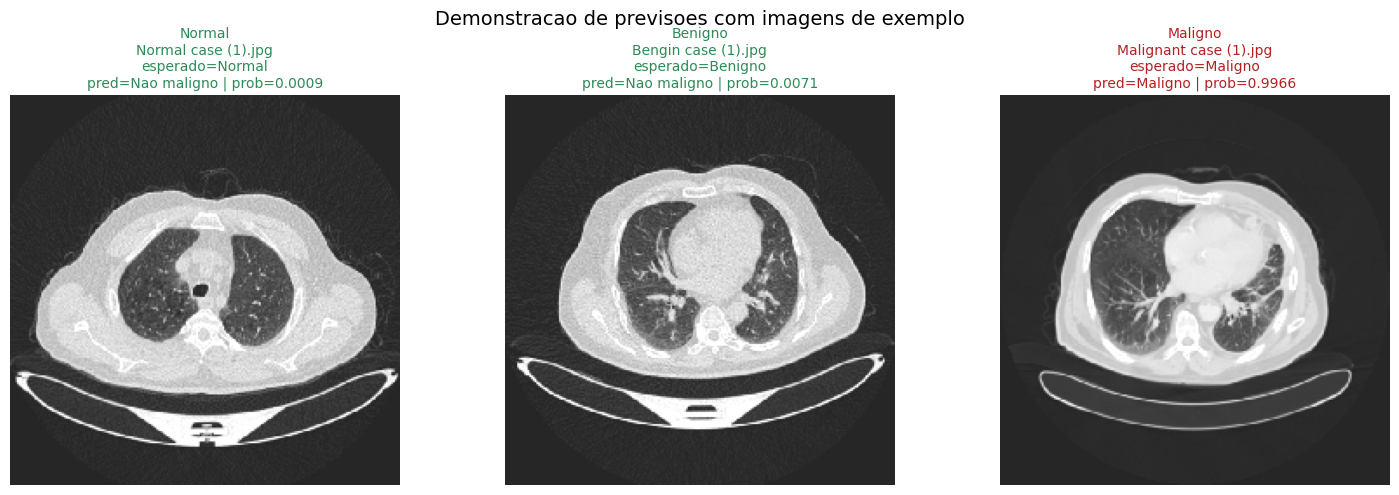


Resumo dos exemplos:
 classe                arquivo classe_esperada  probabilidade_malignidade classe_predita
 Normal    Normal case (1).jpg          Normal                     0.0009    Nao maligno
Benigno    Bengin case (1).jpg         Benigno                     0.0071    Nao maligno
Maligno Malignant case (1).jpg         Maligno                     0.9966        Maligno


In [11]:
# Rode esta celula depois do treino para ver exemplos reais de previsao.
resultados_exemplo = demonstrar_previsoes_exemplo(
    checkpoint_path=OUTPUT_DIR / "best.keras",
    dataset_dir=DATASET_DIR,
)
